# 🏀 NBA Shot Intelligence — Análisis Exploratorio de Datos

## Objetivo

Este notebook tiene como objetivo explorar y comprender el dataset de lanzamientos de la NBA entre las temporadas 2003-04 y 2024-25.

El análisis permitirá estudiar la evolución de la selección y eficiencia de los lanzamientos, identificar patrones asociados a jugadores, zonas y tipos de tiro, y preparar los datos para las posteriores etapas de Machine Learning.

### Objetivos principales

- Comprender la estructura y calidad del dataset.
- Analizar la distribución y eficiencia de los lanzamientos.
- Estudiar la evolución histórica de la selección de tiro.
- Analizar diferencias según zona, distancia y tipo de lanzamiento.
- Explorar patrones individuales de jugadores.
- Identificar variables relevantes para el posterior modelo predictivo.

In [2]:
#Importacion de Linrerias
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [3]:
#Ruta del dataset
DATA_PATH = Path("../data/raw/NBA_2004_2025_Shots.csv")

DATA_PATH

WindowsPath('../data/raw/NBA_2004_2025_Shots.csv')

In [4]:
#Carga eficiente del dataset
dtype_config = {
    "SEASON_1": "category",
    "SEASON_2": "category",
    "TEAM_ID": "int32",
    "TEAM_NAME": "category",
    "PLAYER_ID": "int32",
    "PLAYER_NAME": "category",
    "GAME_ID": "int32",
    "HOME_TEAM": "category",
    "AWAY_TEAM": "category",
    "EVENT_TYPE": "category",
    "SHOT_MADE": "bool",
    "ACTION_TYPE": "category",
    "SHOT_TYPE": "category",
    "BASIC_ZONE": "category",
    "ZONE_NAME": "category",
    "ZONE_ABB": "category",
    "ZONE_RANGE": "category",
    "LOC_X": "float32",
    "LOC_Y": "float32",
    "SHOT_DISTANCE": "int16",
    "QUARTER": "int8",
    "MINS_LEFT": "int8",
    "SECS_LEFT": "int8",
}

In [5]:
#dataset
df = pd.read_csv(
    DATA_PATH,
    dtype=dtype_config,
    parse_dates=["GAME_DATE"]
)

## 1. Descripción general del dataset

En esta sección se analiza la estructura general del dataset, incluyendo sus dimensiones, variables disponibles, tipos de datos y principales características.

In [6]:
df.head()

,SEASON_1,SEASON_2,TEAM_ID,TEAM_NAME,PLAYER_ID,PLAYER_NAME,GAME_DATE,GAME_ID,HOME_TEAM,AWAY_TEAM,EVENT_TYPE,SHOT_MADE,ACTION_TYPE,SHOT_TYPE,BASIC_ZONE,ZONE_NAME,ZONE_ABB,ZONE_RANGE,LOC_X,LOC_Y,SHOT_DISTANCE,QUARTER,MINS_LEFT,SECS_LEFT
0,2025,2024-25,1610612737,Atlanta Hawks,1642258,Zaccharie Risacher,2024-11-12,22400001,BOS,ATL,Missed Shot,False,Jump Shot,3PT Field Goal,Above the Break 3,Left Side Center,LC,24+ ft.,16.799999,25.750000,26,1,11,43
1,2025,2024-25,1610612737,Atlanta Hawks,1630552,Jalen Johnson,2024-11-12,22400001,BOS,ATL,Missed Shot,False,Driving Floating Bank Jump Shot,2PT Field Goal,Mid-Range,Left Side,L,8-16 ft.,13.600000,5.150000,13,1,11,38
2,2025,2024-25,1610612737,Atlanta Hawks,1630552,Jalen Johnson,2024-11-12,22400001,BOS,ATL,Made Shot,True,Jump Shot,3PT Field Goal,Above the Break 3,Right Side Center,RC,24+ ft.,-15.700000,25.549999,25,1,10,50
3,2025,2024-25,1610612737,Atlanta Hawks,1630811,Keaton Wallace,2024-11-12,22400001,BOS,ATL,Missed Shot,False,Jump Shot,3PT Field Goal,Above the Break 3,Left Side Center,LC,24+ ft.,17.600000,23.650000,25,1,9,47
4,2025,2024-25,1610612737,Atlanta Hawks,203991,Clint Capela,2024-11-12,22400001,BOS,ATL,Made Shot,True,Putback Layup Shot,2PT Field Goal,Restricted Area,Center,C,Less Than 8 ft.,2.500000,6.050000,2,1,9,44


In [7]:
print(f"Cantidad de registros: {df.shape[0]:,}")
print(f"Cantidad de columnas: {df.shape[1]}")

Cantidad de registros: 4,443,714
Cantidad de columnas: 24


### Tipos de valores

In [8]:
df.dtypes

SEASON_1               category
SEASON_2               category
TEAM_ID                   int32
TEAM_NAME              category
PLAYER_ID                 int32
PLAYER_NAME            category
GAME_DATE        datetime64[us]
GAME_ID                   int32
HOME_TEAM              category
AWAY_TEAM              category
EVENT_TYPE             category
SHOT_MADE                  bool
ACTION_TYPE            category
SHOT_TYPE              category
BASIC_ZONE             category
ZONE_NAME              category
ZONE_ABB               category
ZONE_RANGE             category
LOC_X                   float32
LOC_Y                   float32
SHOT_DISTANCE             int16
QUARTER                    int8
MINS_LEFT                  int8
SECS_LEFT                  int8
dtype: object

In [9]:
df.nunique().sort_values(ascending=False)

GAME_ID          26457
GAME_DATE         3517
PLAYER_NAME       2281
PLAYER_ID         2263
LOC_Y              913
LOC_X              501
SHOT_DISTANCE       90
ACTION_TYPE         70
SECS_LEFT           60
TEAM_NAME           36
AWAY_TEAM           34
HOME_TEAM           34
TEAM_ID             30
SEASON_1            22
SEASON_2            22
MINS_LEFT           13
QUARTER              8
BASIC_ZONE           7
ZONE_ABB             6
ZONE_NAME            6
ZONE_RANGE           5
SHOT_TYPE            2
EVENT_TYPE           2
SHOT_MADE            2
dtype: int64

## 2. Calidad de los datos

Se evalúa la presencia de valores faltantes y registros duplicados con el objetivo de identificar posibles problemas de calidad antes de comenzar el análisis exploratorio.

In [10]:
#Valores faltantes

total_missing = df.isnull().sum().sum()

print(f"Valores faltantes totales: {total_missing:,}")
print(f"Porcentaje de valores faltantes: {(total_missing / df.size) * 100:.2f}%")

Valores faltantes totales: 0
Porcentaje de valores faltantes: 0.00%


In [11]:
#Valores Duplicados

duplicates = df.duplicated().sum()

print(f"Registros duplicados: {duplicates:,}")
print(f"Porcentaje de duplicados: {(duplicates / len(df)) * 100:.4f}%")

Registros duplicados: 202
Porcentaje de duplicados: 0.0045%


In [12]:
df = df.drop_duplicates().reset_index(drop=True)

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
print(f"Cantidad de registros: {df.shape[0]:,}")
print(f"Cantidad de columnas: {df.shape[1]}")

Cantidad de registros: 4,443,512
Cantidad de columnas: 24


## 3. Cobertura del dataset

Se analiza el período temporal cubierto por los datos y la cantidad de temporadas, jugadores, equipos y partidos incluidos.

In [15]:
print(f"Fecha inicial: {df['GAME_DATE'].min().date()}")
print(f"Fecha final: {df['GAME_DATE'].max().date()}")
print(f"Temporadas: {df['SEASON_1'].nunique()}")
print(f"Jugadores: {df['PLAYER_ID'].nunique():,}")
print(f"Equipos: {df['TEAM_ID'].nunique()}")
print(f"Partidos: {df['GAME_ID'].nunique():,}")

Fecha inicial: 2003-10-28
Fecha final: 2025-04-13
Temporadas: 22
Jugadores: 2,263
Equipos: 30
Partidos: 26,457


In [16]:
df["SEASON_1"].value_counts().sort_index()

SEASON_1
2025    212442
2024    218687
2023    217207
2022    216718
2021    190971
2020    188100
2019    219443
2018    211693
2017    209929
2016    207893
2015    205550
2014    204125
2013    201579
2012    161205
2011    199761
2010    200955
2009    199011
2008    200490
2007    196054
2006    194299
2005    197612
2004    189788
Name: count, dtype: int64

In [17]:
#Estadisticas descriptivas 

numeric_cols = [
    "LOC_X",
    "LOC_Y",
    "SHOT_DISTANCE",
    "QUARTER",
    "MINS_LEFT",
    "SECS_LEFT"
]

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
LOC_X,4443512.0,0.131430,11.119513,-25.00,-5.10,-0.00,5.500000,25.000000
LOC_Y,4443512.0,13.612606,9.040216,0.05,5.95,9.65,20.950001,93.650002
SHOT_DISTANCE,4443512.0,12.631658,10.157069,0.00,2.00,13.00,23.000000,89.000000
QUARTER,4443512.0,2.480643,1.137036,1.00,1.00,2.00,3.000000,8.000000
MINS_LEFT,4443512.0,5.341610,3.462393,0.00,2.00,5.00,8.000000,12.000000
SECS_LEFT,4443512.0,28.775351,17.447435,0.00,14.00,29.00,44.000000,59.000000


## 4. Distribución de la variable objetivo

La variable `SHOT_MADE` indica si un lanzamiento fue convertido (`True`) o fallado (`False`). Esta variable será utilizada posteriormente como objetivo del modelo predictivo.

In [18]:
df["SHOT_MADE"].value_counts()

SHOT_MADE
False    2407805
True     2035707
Name: count, dtype: int64

In [19]:
shot_distribution = (
    df["SHOT_MADE"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

shot_distribution

SHOT_MADE
False    54.19
True     45.81
Name: proportion, dtype: float64

## 5. Análisis de los lanzamientos

En esta sección se analiza cómo se distribuyen los lanzamientos según su valor, zona y distancia, así como la eficiencia obtenida desde cada sector de la cancha.

El objetivo es comprender los principales patrones de selección de tiro antes de estudiar su evolución histórica.

In [20]:
#Cantidad de tiros: 2pt vs 3pt
shot_type_counts = df["SHOT_TYPE"].value_counts()

shot_type_counts

SHOT_TYPE
2PT Field Goal    3147597
3PT Field Goal    1295915
Name: count, dtype: int64

In [21]:
shot_type_pct = (
    df["SHOT_TYPE"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

shot_type_pct

SHOT_TYPE
2PT Field Goal    70.84
3PT Field Goal    29.16
Name: proportion, dtype: float64

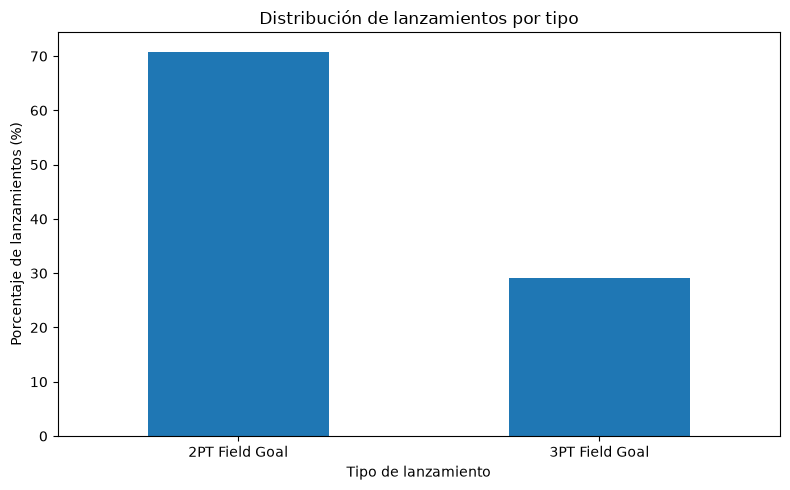

In [22]:
shot_type_pct.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Distribución de lanzamientos por tipo")
plt.xlabel("Tipo de lanzamiento")
plt.ylabel("Porcentaje de lanzamientos (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [23]:
#Eficiencia 2pt vs 3pt
shot_type_efficiency = (
    df.groupby("SHOT_TYPE", observed=True)["SHOT_MADE"]
    .mean()
    .mul(100)
    .round(2)
)

shot_type_efficiency

SHOT_TYPE
2PT Field Goal    49.92
3PT Field Goal    35.83
Name: SHOT_MADE, dtype: float64

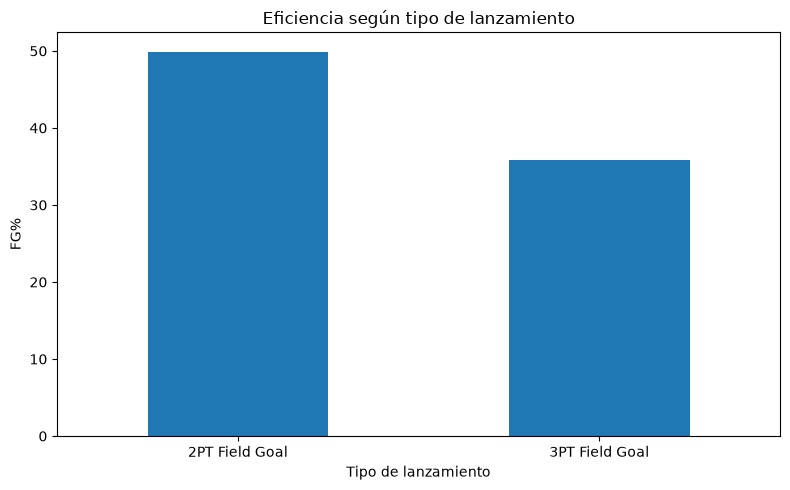

In [24]:
shot_type_efficiency.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Eficiencia según tipo de lanzamiento")
plt.xlabel("Tipo de lanzamiento")
plt.ylabel("FG%")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Análisis por zona

Se analiza la distribución, eficiencia y valor generado por los lanzamientos según las diferentes zonas de la cancha.

In [25]:
#Analisis por zona
zone_counts = df["BASIC_ZONE"].value_counts()

zone_counts

BASIC_ZONE
Restricted Area          1403040
Mid-Range                1058599
Above the Break 3         956333
In The Paint (Non-RA)     686914
Left Corner 3             171516
Right Corner 3            157780
Backcourt                   9330
Name: count, dtype: int64

In [26]:
#Porcentaje
zone_pct = (
    df["BASIC_ZONE"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

zone_pct

BASIC_ZONE
Restricted Area          31.58
Mid-Range                23.82
Above the Break 3        21.52
In The Paint (Non-RA)    15.46
Left Corner 3             3.86
Right Corner 3            3.55
Backcourt                 0.21
Name: proportion, dtype: float64

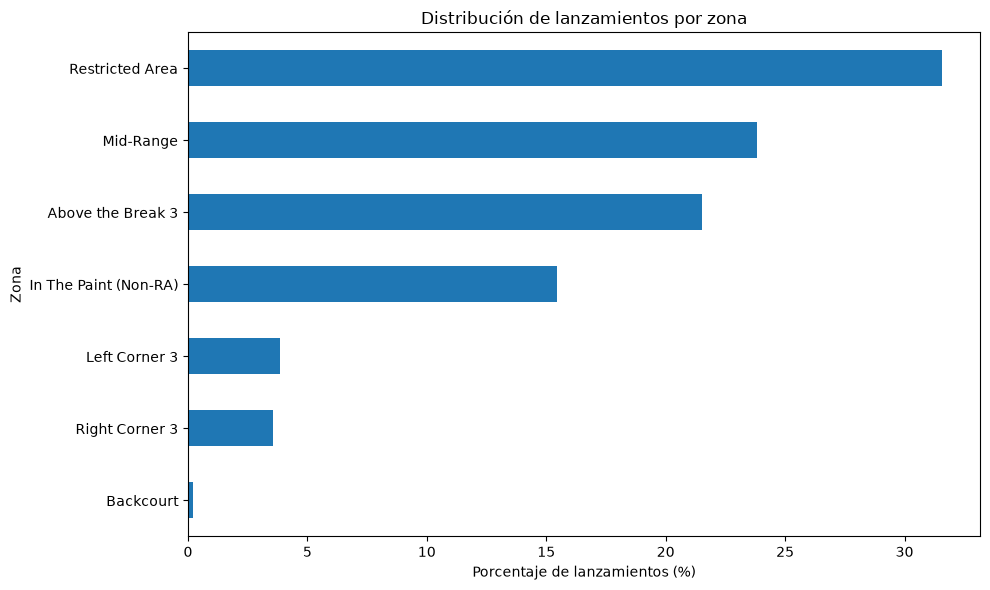

In [27]:
zone_pct.sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Distribución de lanzamientos por zona")
plt.xlabel("Porcentaje de lanzamientos (%)")
plt.ylabel("Zona")
plt.tight_layout()
plt.show()

In [28]:
#Eficiencia por zona 
zone_analysis = (
    df.groupby("BASIC_ZONE", observed=True)
    .agg(
        attempts=("SHOT_MADE", "size"),
        made=("SHOT_MADE", "sum"),
        fg_pct=("SHOT_MADE", "mean")
    )
    .reset_index()
)

zone_analysis["fg_pct"] = (zone_analysis["fg_pct"] * 100).round(2)

zone_analysis = zone_analysis.sort_values(
    "fg_pct",
    ascending=False
)

zone_analysis

,BASIC_ZONE,attempts,made,fg_pct
5,Restricted Area,1403040,867040,61.80
2,In The Paint (Non-RA),686914,282279,41.09
4,Mid-Range,1058599,422423,39.90
6,Right Corner 3,157780,61265,38.83
3,Left Corner 3,171516,66262,38.63
0,Above the Break 3,956333,336210,35.16
1,Backcourt,9330,228,2.44


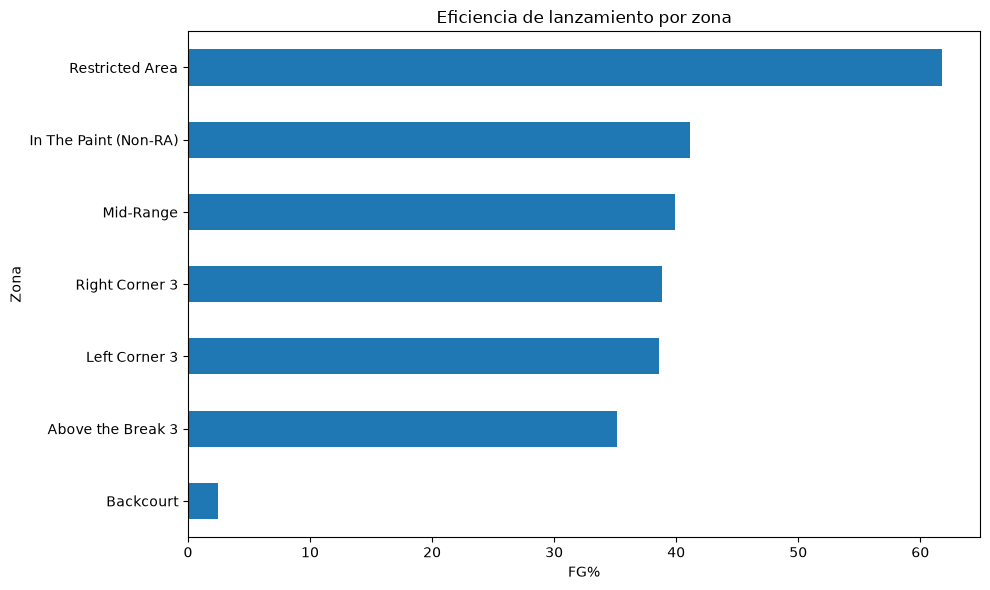

In [29]:
zone_efficiency = zone_analysis.set_index("BASIC_ZONE")["fg_pct"]

zone_efficiency.sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Eficiencia de lanzamiento por zona")
plt.xlabel("FG%")
plt.ylabel("Zona")
plt.tight_layout()
plt.show()

## 7. Puntos por intento

Además del porcentaje de campo, se analiza la producción de puntos por lanzamiento para considerar el diferente valor de los tiros de dos y tres puntos.

In [30]:
#Puntos esperados por intento
df["SHOT_VALUE"] = (
    df["SHOT_TYPE"]
    .astype(str)
    .str.extract(r"(\d)")
    .astype("int8")
)

In [31]:
df[["SHOT_TYPE", "SHOT_VALUE"]].drop_duplicates()

,SHOT_TYPE,SHOT_VALUE
0,3PT Field Goal,3
1,2PT Field Goal,2


In [32]:
df["POINTS"] = df["SHOT_MADE"].astype("int8") * df["SHOT_VALUE"]

In [33]:
df[["SHOT_MADE", "SHOT_VALUE", "POINTS"]].head(10)

,SHOT_MADE,SHOT_VALUE,POINTS
0,False,3,0
1,False,2,0
2,True,3,3
3,False,3,0
4,True,2,2
5,True,2,2
6,False,2,0
7,False,2,0
8,False,2,0
9,False,2,0


In [34]:
#Eficiencia por zona
zone_value = (
    df.groupby("BASIC_ZONE", observed=True)
    .agg(
        attempts=("SHOT_MADE", "size"),
        fg_pct=("SHOT_MADE", "mean"),
        points=("POINTS", "sum")
    )
    .reset_index()
)

zone_value["fg_pct"] = (zone_value["fg_pct"] * 100).round(2)

zone_value["points_per_attempt"] = (
    zone_value["points"] / zone_value["attempts"]
).round(2)

zone_value = zone_value.sort_values(
    "points_per_attempt",
    ascending=False
)

zone_value

,BASIC_ZONE,attempts,fg_pct,points,points_per_attempt
5,Restricted Area,1403040,61.80,1734100,1.24
3,Left Corner 3,171516,38.63,198781,1.16
6,Right Corner 3,157780,38.83,183752,1.16
0,Above the Break 3,956333,35.16,1008584,1.05
2,In The Paint (Non-RA),686914,41.09,564559,0.82
4,Mid-Range,1058599,39.90,845282,0.80
1,Backcourt,9330,2.44,684,0.07


## 8. Análisis según distancia

Se analiza la relación entre la distancia al aro, el volumen de lanzamientos y la probabilidad de conversión.

In [35]:
df["SHOT_DISTANCE"].describe()

count    4.443512e+06
mean     1.263166e+01
std      1.015707e+01
min      0.000000e+00
25%      2.000000e+00
50%      1.300000e+01
75%      2.300000e+01
max      8.900000e+01
Name: SHOT_DISTANCE, dtype: float64

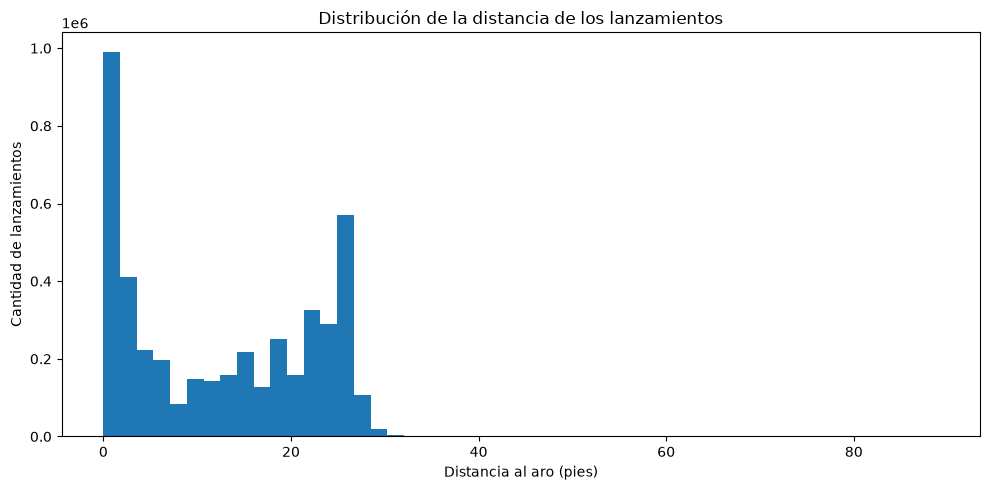

In [36]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["SHOT_DISTANCE"],
    bins=50
)

plt.title("Distribución de la distancia de los lanzamientos")
plt.xlabel("Distancia al aro (pies)")
plt.ylabel("Cantidad de lanzamientos")
plt.tight_layout()
plt.show()

In [37]:
#Distancia vs eficiencia
distance_efficiency = (
    df.groupby("SHOT_DISTANCE")
    .agg(
        attempts=("SHOT_MADE", "size"),
        fg_pct=("SHOT_MADE", "mean")
    )
    .reset_index()
)

distance_efficiency["fg_pct"] *= 100

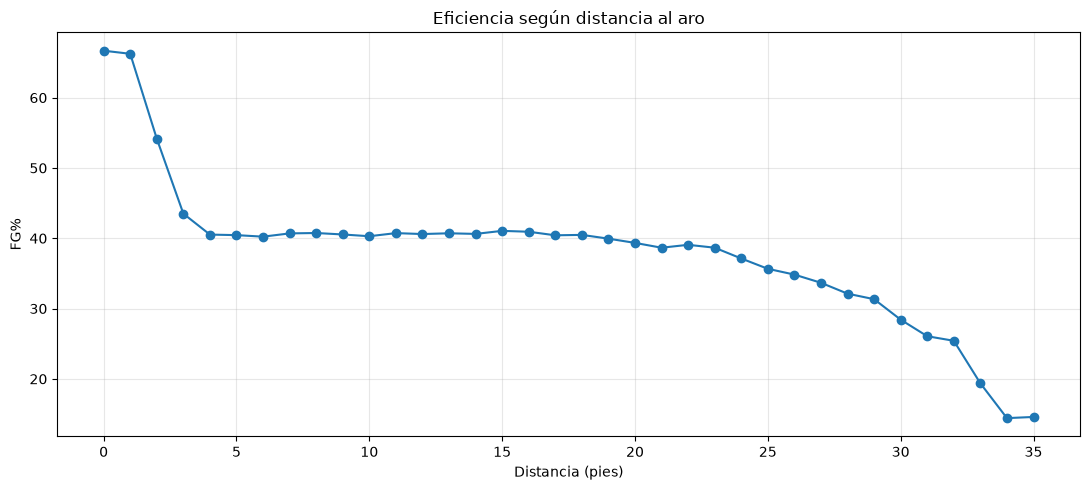

In [38]:
distance_plot = distance_efficiency[
    distance_efficiency["SHOT_DISTANCE"] <= 35
]

plt.figure(figsize=(11, 5))

plt.plot(
    distance_plot["SHOT_DISTANCE"],
    distance_plot["fg_pct"],
    marker="o"
)

plt.title("Eficiencia según distancia al aro")
plt.xlabel("Distancia (pies)")
plt.ylabel("FG%")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Evolución histórica de la selección de tiro

En esta sección se analiza cómo evolucionó el perfil de lanzamiento de la NBA entre las temporadas 2003-04 y 2024-25.

Se estudian los cambios en la frecuencia de tiros de tres puntos, tiros de media distancia y lanzamientos cercanos al aro, además de la evolución de la distancia promedio y la eficiencia de tiro.

In [39]:
# Orden cronológico de las temporadas
season_order = sorted(df["SEASON_1"].unique())

In [40]:
#Evolucion del triple
three_point_evolution = (
    df.assign(IS_3PT=df["SHOT_TYPE"].eq("3PT Field Goal"))
    .groupby("SEASON_1", observed=True)["IS_3PT"]
    .mean()
    .mul(100)
    .round(2)
    .reindex(season_order)
)

three_point_evolution

SEASON_1
2004    18.70
2005    19.61
2006    20.23
2007    21.25
2008    22.22
2009    22.39
2010    22.19
2011    22.17
2012    22.56
2013    24.33
2014    25.93
2015    26.81
2016    28.42
2017    31.55
2018    33.70
2019    35.88
2020    38.41
2021    39.18
2022    39.93
2023    38.75
2024    39.49
2025    42.23
Name: IS_3PT, dtype: float64

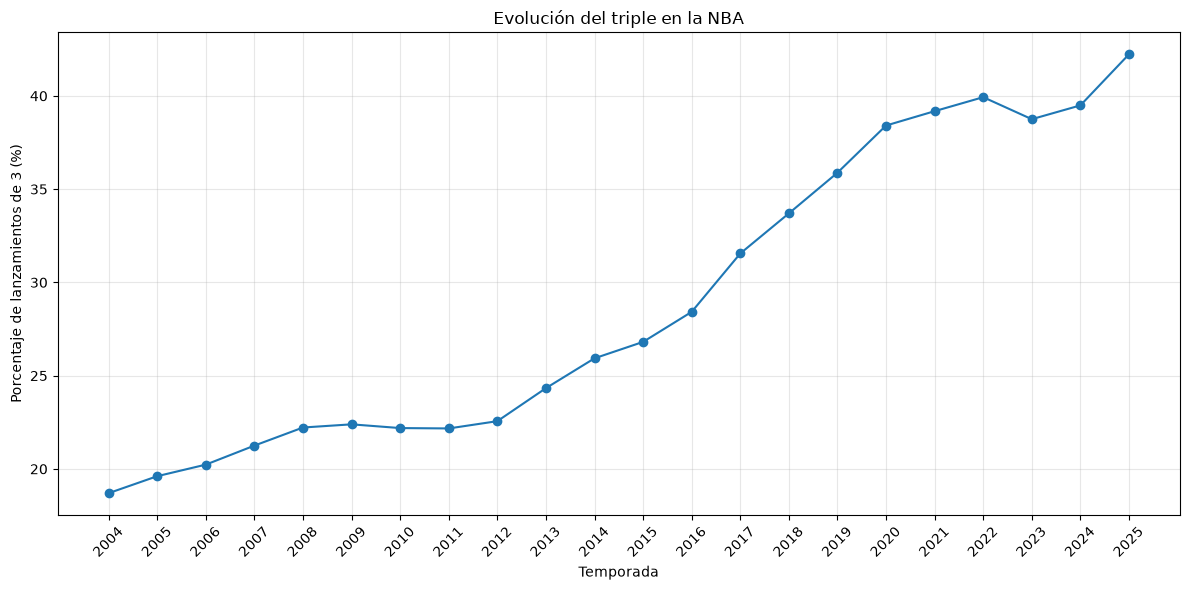

In [41]:
plt.figure(figsize=(12, 6))

plt.plot(
    three_point_evolution.index,
    three_point_evolution.values,
    marker="o"
)

plt.title("Evolución del triple en la NBA")
plt.xlabel("Temporada")
plt.ylabel("Porcentaje de lanzamientos de 3 (%)")

plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [42]:
#Evolucion del Mid-range
midrange_evolution = (
    df.assign(IS_MIDRANGE=df["BASIC_ZONE"].eq("Mid-Range"))
    .groupby("SEASON_1", observed=True)["IS_MIDRANGE"]
    .mean()
    .mul(100)
    .round(2)
    .reindex(season_order)
)

midrange_evolution

SEASON_1
2004    35.65
2005    35.44
2006    34.44
2007    33.03
2008    32.91
2009    32.15
2010    31.43
2011    31.01
2012    30.26
2013    28.32
2014    26.81
2015    26.16
2016    24.60
2017    22.19
2018    19.05
2019    15.16
2020    13.33
2021    12.86
2022    12.79
2023    11.86
2024    11.24
2025     9.77
Name: IS_MIDRANGE, dtype: float64

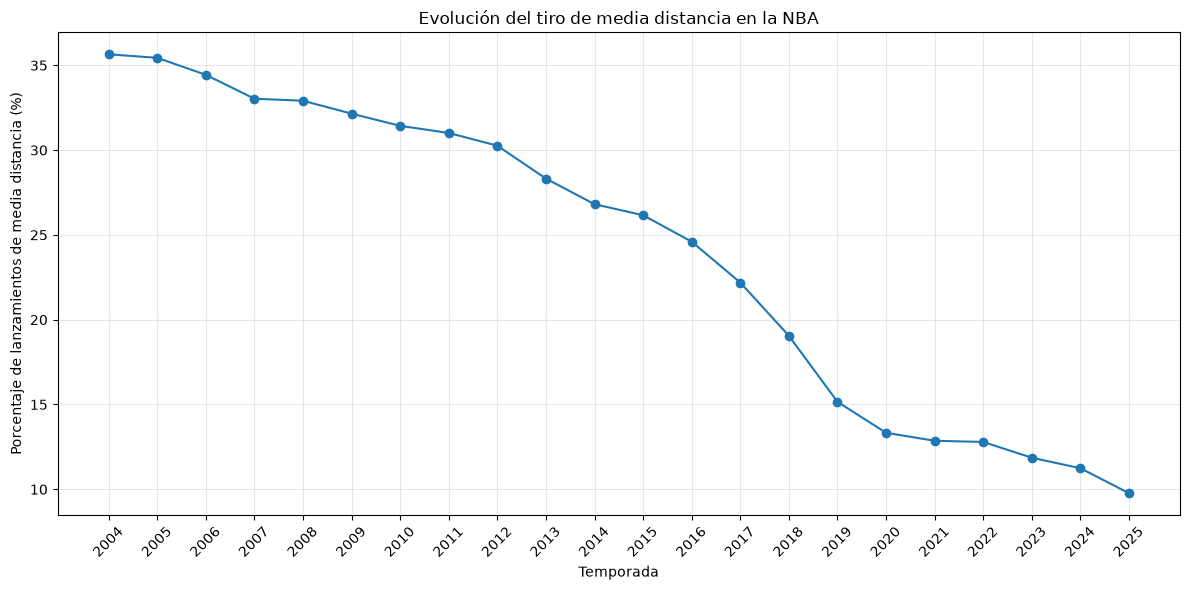

In [43]:
plt.figure(figsize=(12, 6))

plt.plot(
    midrange_evolution.index,
    midrange_evolution.values,
    marker="o"
)

plt.title("Evolución del tiro de media distancia en la NBA")
plt.xlabel("Temporada")
plt.ylabel("Porcentaje de lanzamientos de media distancia (%)")

plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [44]:
#Triple vs Mid-range
shot_evolution = pd.DataFrame({
    "3PT": three_point_evolution,
    "Mid-Range": midrange_evolution
})

shot_evolution

,3PT,Mid-Range
SEASON_1,,
2004,18.70,35.65
2005,19.61,35.44
2006,20.23,34.44
2007,21.25,33.03
2008,22.22,32.91
2009,22.39,32.15
2010,22.19,31.43
2011,22.17,31.01
2012,22.56,30.26


In [45]:
shot_evolution = shot_evolution.reindex(season_order)

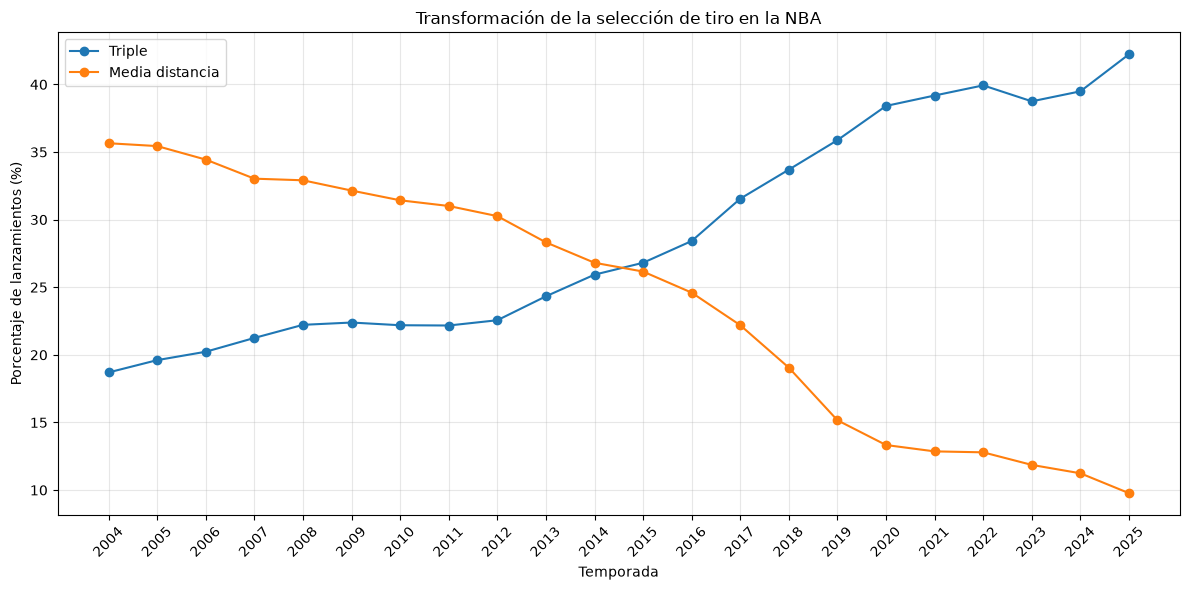

In [46]:
plt.figure(figsize=(12, 6))

plt.plot(
    shot_evolution.index,
    shot_evolution["3PT"],
    marker="o",
    label="Triple"
)

plt.plot(
    shot_evolution.index,
    shot_evolution["Mid-Range"],
    marker="o",
    label="Media distancia"
)

plt.title("Transformación de la selección de tiro en la NBA")
plt.xlabel("Temporada")
plt.ylabel("Porcentaje de lanzamientos (%)")

plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../reports/figures/shot_selection_evolution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [47]:
#Evolucion de todas las zonas
zone_evolution = (
    pd.crosstab(
        df["SEASON_1"],
        df["BASIC_ZONE"],
        normalize="index"
    )
    .mul(100)
    .round(2)
    .reindex(season_order)
)

zone_evolution

BASIC_ZONE,Above the Break 3,Backcourt,In The Paint (Non-RA),Left Corner 3,Mid-Range,Restricted Area,Right Corner 3
SEASON_1,,,,,,,
2004,13.46,0.18,14.40,2.67,35.65,31.27,2.37
2005,13.90,0.18,13.03,2.80,35.44,31.96,2.69
2006,14.32,0.19,12.92,2.92,34.44,32.43,2.78
2007,15.06,0.19,12.86,3.21,33.03,32.89,2.76
2008,15.88,0.23,12.92,3.16,32.91,31.98,2.90
2009,15.75,0.22,12.77,3.39,32.15,32.73,2.99
2010,16.04,0.24,13.15,3.12,31.43,33.22,2.80
2011,15.76,0.23,15.31,3.24,31.01,31.50,2.94
2012,16.31,0.19,14.85,3.10,30.26,32.32,2.97


In [48]:
zone_evolution = zone_evolution.reindex(season_order)

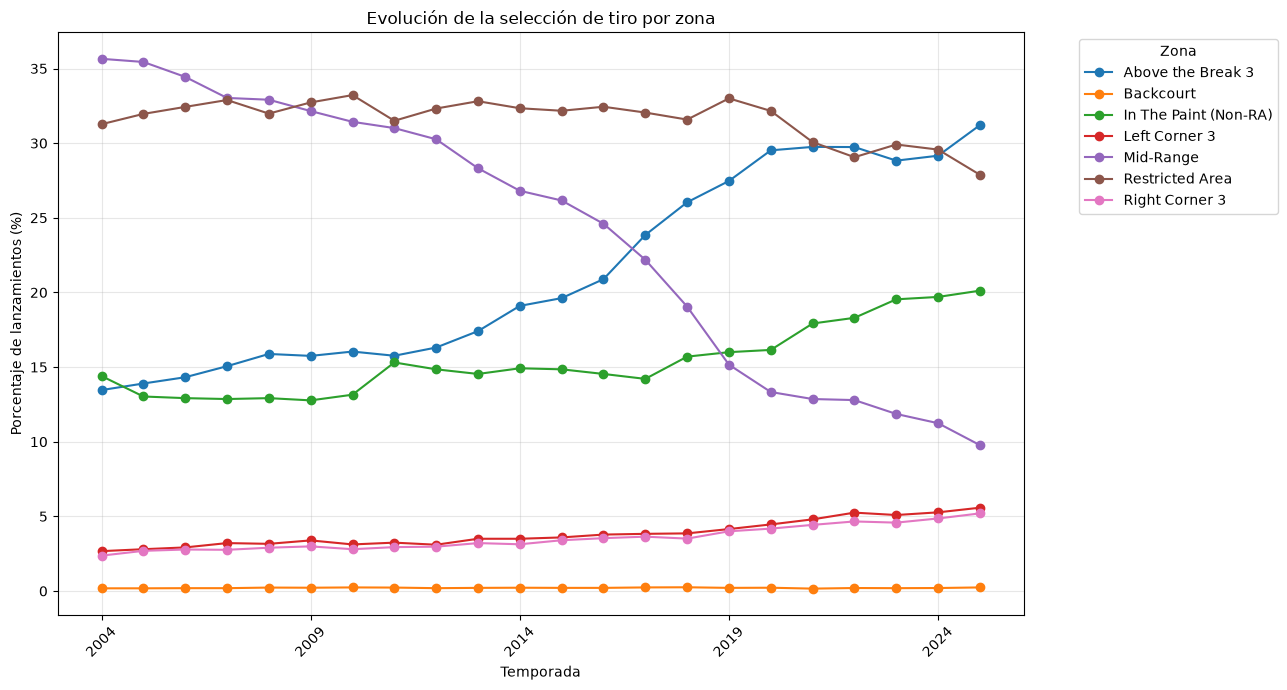

In [49]:
zone_evolution.plot(
    figsize=(13, 7),
    marker="o"
)

plt.title("Evolución de la selección de tiro por zona")
plt.xlabel("Temporada")
plt.ylabel("Porcentaje de lanzamientos (%)")

plt.xticks(rotation=45)
plt.legend(
    title="Zona",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [50]:
#Distancia promedio de lanzamiento
distance_evolution = (
    df.groupby("SEASON_1", observed=True)["SHOT_DISTANCE"]
    .mean()
    .round(2)
    .reindex(season_order)
)

distance_evolution

SEASON_1
2004    11.60
2005    11.74
2006    11.79
2007    11.82
2008    12.15
2009    12.02
2010    11.85
2011    12.14
2012    12.06
2013    12.16
2014    12.30
2015    12.36
2016    12.46
2017    12.85
2018    13.16
2019    13.06
2020    13.41
2021    13.62
2022    13.80
2023    13.46
2024    13.54
2025    14.02
Name: SHOT_DISTANCE, dtype: float64

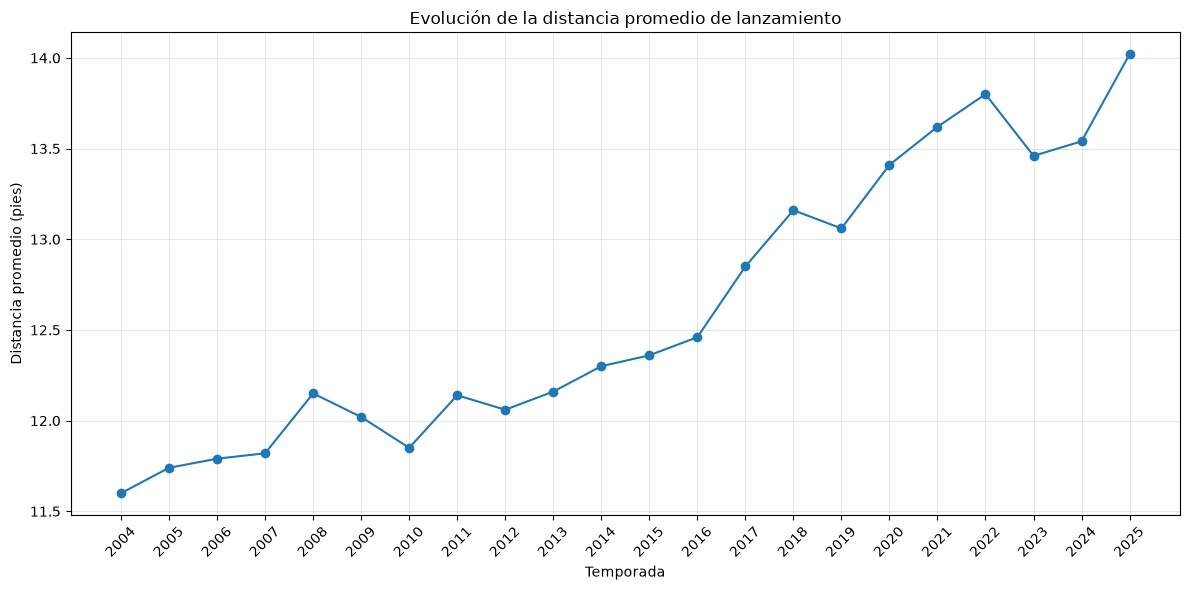

In [51]:
plt.figure(figsize=(12, 6))

plt.plot(
    distance_evolution.index,
    distance_evolution.values,
    marker="o"
)

plt.title("Evolución de la distancia promedio de lanzamiento")
plt.xlabel("Temporada")
plt.ylabel("Distancia promedio (pies)")

plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [52]:
#Evolución del FG%
fg_evolution = (
    df.groupby("SEASON_1", observed=True)["SHOT_MADE"]
    .mean()
    .mul(100)
    .round(2)
    .reindex(season_order)
)

fg_evolution

SEASON_1
2004    43.87
2005    44.75
2006    45.38
2007    45.83
2008    45.72
2009    45.88
2010    46.14
2011    45.86
2012    44.79
2013    45.28
2014    45.45
2015    44.89
2016    45.22
2017    45.72
2018    46.03
2019    46.05
2020    46.01
2021    46.61
2022    46.11
2023    47.54
2024    47.44
2025    46.67
Name: SHOT_MADE, dtype: float64

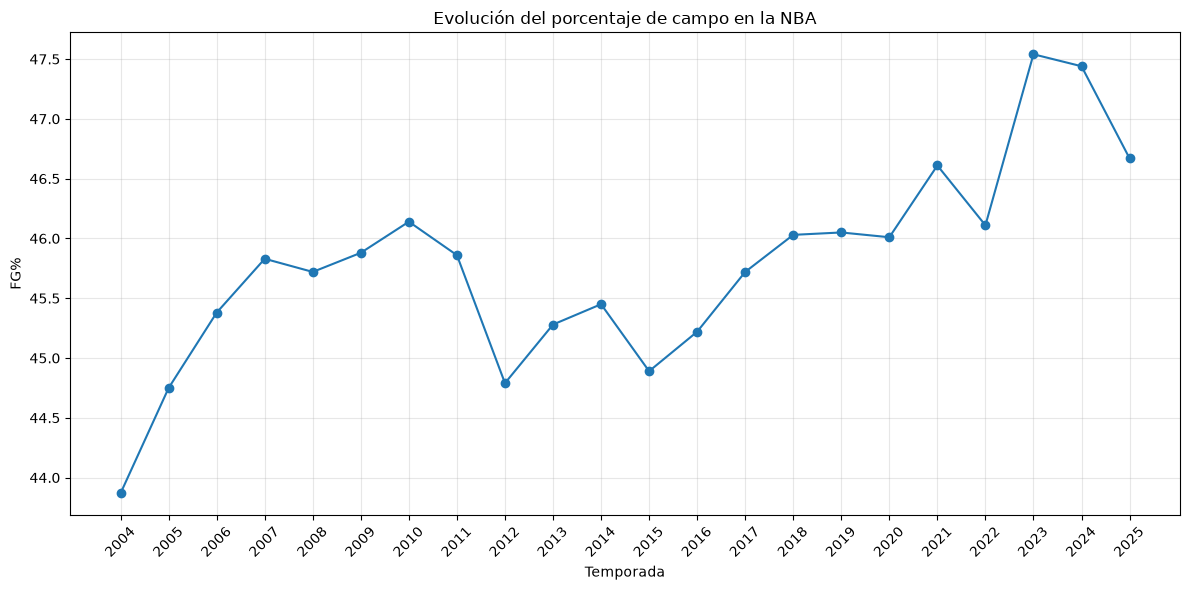

In [53]:
plt.figure(figsize=(12, 6))

plt.plot(
    fg_evolution.index,
    fg_evolution.values,
    marker="o"
)

plt.title("Evolución del porcentaje de campo en la NBA")
plt.xlabel("Temporada")
plt.ylabel("FG%")

plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [54]:
#Evolucion de puntos por intento
ppa_evolution = (
    df.groupby("SEASON_1", observed=True)["POINTS"]
    .mean()
    .round(2)
    .reindex(season_order)
)

ppa_evolution

SEASON_1
2004    0.94
2005    0.96
2006    0.98
2007    0.99
2008    0.99
2009    1.00
2010    1.00
2011    1.00
2012    0.97
2013    0.99
2014    1.00
2015    0.99
2016    1.01
2017    1.03
2018    1.04
2019    1.05
2020    1.06
2021    1.08
2022    1.06
2023    1.09
2024    1.09
2025    1.09
Name: POINTS, dtype: float64

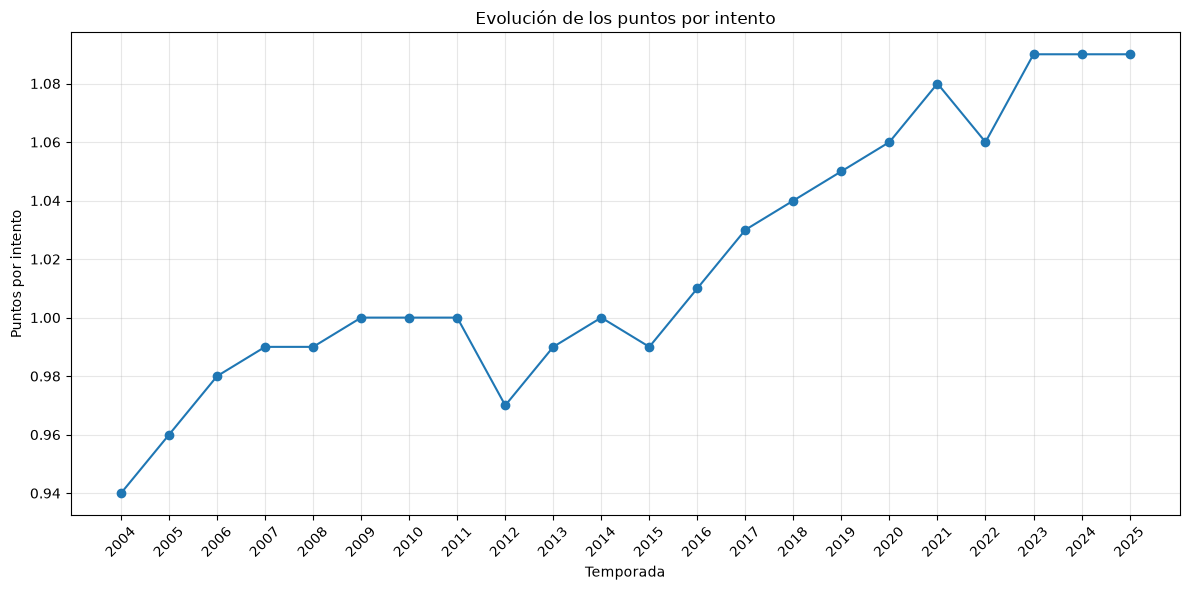

In [55]:
plt.figure(figsize=(12, 6))

plt.plot(
    ppa_evolution.index,
    ppa_evolution.values,
    marker="o"
)

plt.title("Evolución de los puntos por intento")
plt.xlabel("Temporada")
plt.ylabel("Puntos por intento")

plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [56]:
#Tabla resumen: 2003-04 vs 2024-25
historical_comparison = pd.DataFrame({
    "3PT %": three_point_evolution,
    "Mid-Range %": midrange_evolution,
    "Distancia promedio": distance_evolution,
    "FG %": fg_evolution,
    "Puntos por intento": ppa_evolution
})

historical_comparison.loc[["2004", "2025"]]

,3PT %,Mid-Range %,Distancia promedio,FG %,Puntos por intento
SEASON_1,,,,,
2004,18.70,35.65,11.60,43.87,0.94
2025,42.23,9.77,14.02,46.67,1.09


## 10. Conclusiones del análisis histórico

El análisis de las temporadas 2003-04 a 2024-25 evidencia una transformación significativa en la selección de lanzamiento de la NBA.

- La proporción de triples aumentó del **18,70 % al 42,23 %**, un incremento de 23,53 puntos porcentuales.
- Los lanzamientos de media distancia disminuyeron del **35,65 % al 9,77 %**, una caída de 25,88 puntos porcentuales.
- Alrededor de las temporadas **2014-15 y 2015-16**, los triples comenzaron a representar una proporción mayor de los lanzamientos que los tiros de media distancia.
- La distancia promedio de lanzamiento aumentó de **11,60 a 14,02 pies**.
- Los lanzamientos en la zona restringida mantuvieron una participación elevada, indicando que la transformación se produjo principalmente mediante la sustitución de tiros de media distancia por lanzamientos de tres puntos.
- A pesar del aumento de la distancia promedio, el FG% global pasó del **43,87 % al 46,67 %**.
- Los puntos generados por intento aumentaron de **0,94 a 1,09**, mostrando una mejora en la producción ofensiva por lanzamiento.

En conjunto, los datos muestran una evolución hacia un perfil ofensivo centrado principalmente en lanzamientos cercanos al aro y tiros de tres puntos, reduciendo progresivamente la utilización de la media distancia.

## 11. Análisis de jugadores

En esta sección se analizan los jugadores desde una perspectiva individual, considerando volumen de lanzamientos, eficiencia, producción por intento y distribución de tiro.

El objetivo es identificar jugadores con distintos perfiles ofensivos y preparar el análisis para la posterior construcción de shot charts y métricas avanzadas.

In [57]:
#Jugadores con más lanzamientos
player_volume = (
    df.groupby("PLAYER_NAME", observed=True)
    .agg(
        attempts=("SHOT_MADE", "size"),
        made=("SHOT_MADE", "sum")
    )
    .reset_index()
    .sort_values("attempts", ascending=False)
)

player_volume.head(15)

,PLAYER_NAME,attempts,made
245,LeBron James,30581,15488
868,Carmelo Anthony,22641,10119
173,Russell Westbrook,21488,9427
413,Kevin Durant,20999,10542
465,DeMar DeRozan,19314,9064
264,Stephen Curry,18353,8646
1081,Dirk Nowitzki,18285,8637
1416,Kobe Bryant,17869,7916
1083,Dwyane Wade,17615,8454
459,Chris Paul,17351,8147


In [58]:
player_volume["fg_pct"] = (
    player_volume["made"] / player_volume["attempts"] * 100
).round(2)

player_volume.head(15)

,PLAYER_NAME,attempts,made,fg_pct
245,LeBron James,30581,15488,50.65
868,Carmelo Anthony,22641,10119,44.69
173,Russell Westbrook,21488,9427,43.87
413,Kevin Durant,20999,10542,50.20
465,DeMar DeRozan,19314,9064,46.93
264,Stephen Curry,18353,8646,47.11
1081,Dirk Nowitzki,18285,8637,47.24
1416,Kobe Bryant,17869,7916,44.30
1083,Dwyane Wade,17615,8454,47.99
459,Chris Paul,17351,8147,46.95


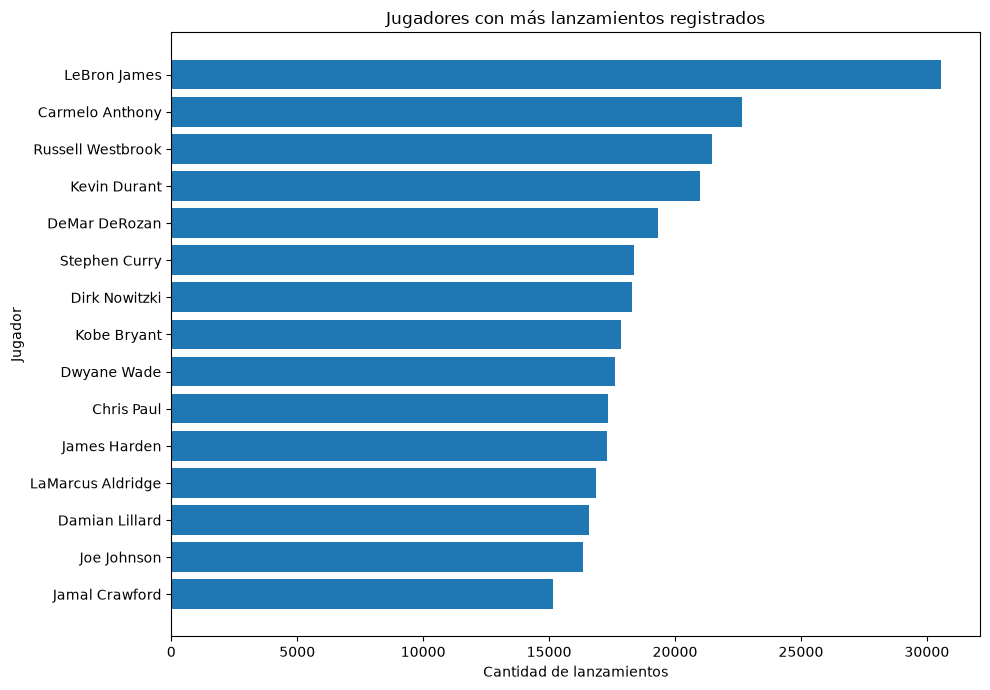

In [59]:
top_attempts = player_volume.head(15).sort_values("attempts")

plt.figure(figsize=(10, 7))

plt.barh(
    top_attempts["PLAYER_NAME"],
    top_attempts["attempts"]
)

plt.title("Jugadores con más lanzamientos registrados")
plt.xlabel("Cantidad de lanzamientos")
plt.ylabel("Jugador")
plt.tight_layout()
plt.show()

In [60]:
#Eficiencia de jugadores
MIN_ATTEMPTS = 5000
efficient_players = (
    player_volume[
        player_volume["attempts"] >= MIN_ATTEMPTS
    ]
    .sort_values("fg_pct", ascending=False)
)

efficient_players.head(15)

,PLAYER_NAME,attempts,made,fg_pct
123,DeAndre Jordan,5724,3856,67.37
350,Rudy Gobert,5949,3903,65.61
11,Clint Capela,5626,3470,61.68
1056,Tyson Chandler,5176,3150,60.86
1788,Shaquille O'Neal,5385,3214,59.68
873,Dwight Howard,12015,7051,58.68
578,JaVale McGee,5109,2955,57.84
617,Jonas Valanciunas,8106,4551,56.14
470,Domantas Sabonis,7266,4068,55.99
684,Nikola Jokic,9775,5450,55.75


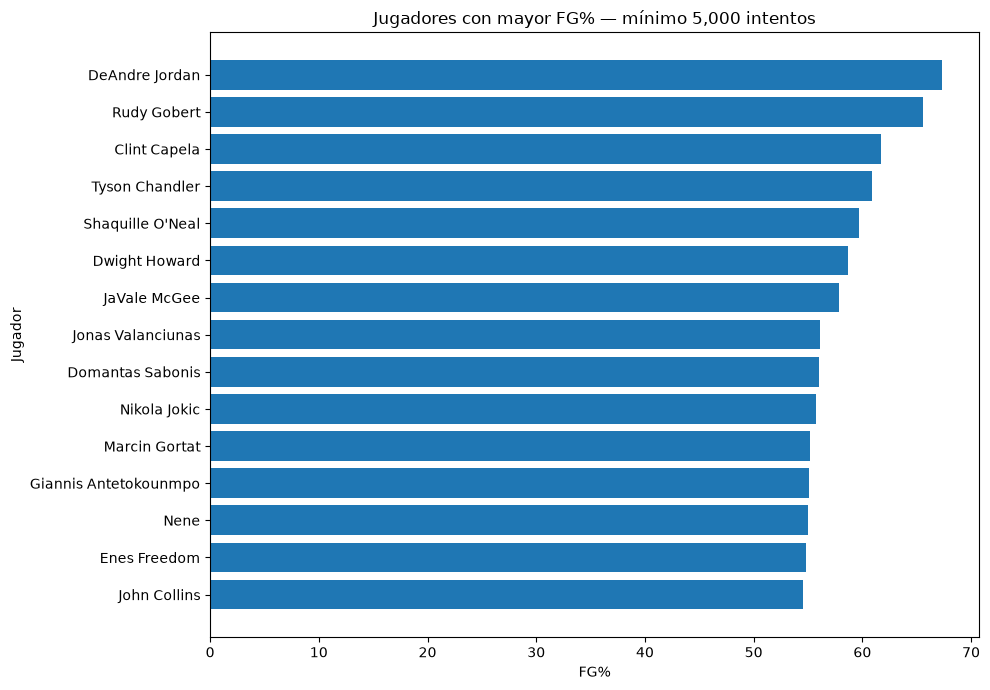

In [61]:
top_efficiency = efficient_players.head(15).sort_values("fg_pct")

plt.figure(figsize=(10, 7))

plt.barh(
    top_efficiency["PLAYER_NAME"],
    top_efficiency["fg_pct"]
)

plt.title(f"Jugadores con mayor FG% — mínimo {MIN_ATTEMPTS:,} intentos")
plt.xlabel("FG%")
plt.ylabel("Jugador")
plt.tight_layout()
plt.show()

In [62]:
#Puntos por intento por jugador
player_analysis = (
    df.groupby("PLAYER_NAME", observed=True)
    .agg(
        attempts=("SHOT_MADE", "size"),
        made=("SHOT_MADE", "sum"),
        points=("POINTS", "sum"),
        avg_distance=("SHOT_DISTANCE", "mean")
    )
    .reset_index()
)

player_analysis["fg_pct"] = (
    player_analysis["made"] / player_analysis["attempts"] * 100
).round(2)

player_analysis["points_per_attempt"] = (
    player_analysis["points"] / player_analysis["attempts"]
).round(2)

player_analysis["avg_distance"] = (
    player_analysis["avg_distance"]
).round(2)

In [63]:
qualified_players = player_analysis[
    player_analysis["attempts"] >= MIN_ATTEMPTS
]

In [64]:
qualified_players.sort_values(
    "points_per_attempt",
    ascending=False
).head(15)

,PLAYER_NAME,attempts,made,points,avg_distance,fg_pct,points_per_attempt
123,DeAndre Jordan,5724,3856,7714,1.47,67.37,1.35
350,Rudy Gobert,5949,3903,7806,1.92,65.61,1.31
11,Clint Capela,5626,3470,6940,1.89,61.68,1.23
1056,Tyson Chandler,5176,3150,6300,2.43,60.86,1.22
1788,Shaquille O'Neal,5385,3214,6428,2.98,59.68,1.19
684,Nikola Jokic,9775,5450,11576,9.81,55.75,1.18
873,Dwight Howard,12015,7051,14124,3.36,58.68,1.18
541,John Collins,5380,2936,6364,9.48,54.57,1.18
409,Karl-Anthony Towns,10421,5460,12037,10.93,52.39,1.16
264,Stephen Curry,18353,8646,21348,18.07,47.11,1.16


In [65]:
#Frecuencia de triples por jugador
df["IS_3PT"] = df["SHOT_TYPE"].eq("3PT Field Goal")

In [66]:
player_shot_profile = (
    df.groupby("PLAYER_NAME", observed=True)
    .agg(
        attempts=("SHOT_MADE", "size"),
        three_pt_rate=("IS_3PT", "mean"),
        avg_distance=("SHOT_DISTANCE", "mean"),
        fg_pct=("SHOT_MADE", "mean")
    )
    .reset_index()
)

player_shot_profile["three_pt_rate"] = (
    player_shot_profile["three_pt_rate"] * 100
).round(2)

player_shot_profile["fg_pct"] = (
    player_shot_profile["fg_pct"] * 100
).round(2)

player_shot_profile["avg_distance"] = (
    player_shot_profile["avg_distance"]
).round(2)

In [67]:
player_shot_profile = player_shot_profile[
    player_shot_profile["attempts"] >= MIN_ATTEMPTS
]

In [68]:
player_shot_profile.sort_values(
    "three_pt_rate",
    ascending=False
).head(15)

,PLAYER_NAME,attempts,three_pt_rate,avg_distance,fg_pct
607,Danny Green,6045,65.24,18.58,42.10
155,Malik Beasley,5702,65.15,18.66,42.60
625,Robert Covington,5466,63.85,17.83,40.87
1041,Kyle Korver,9276,61.59,20.53,44.22
202,Buddy Hield,8985,59.61,18.29,43.25
564,Patty Mills,6722,59.42,19.12,42.32
889,Wayne Ellington,5440,58.35,19.23,41.05
483,Jae Crowder,6192,57.24,17.52,41.83
178,Tim Hardaway Jr.,9258,55.18,17.69,41.69
214,Fred VanVleet,6885,54.19,17.66,40.13


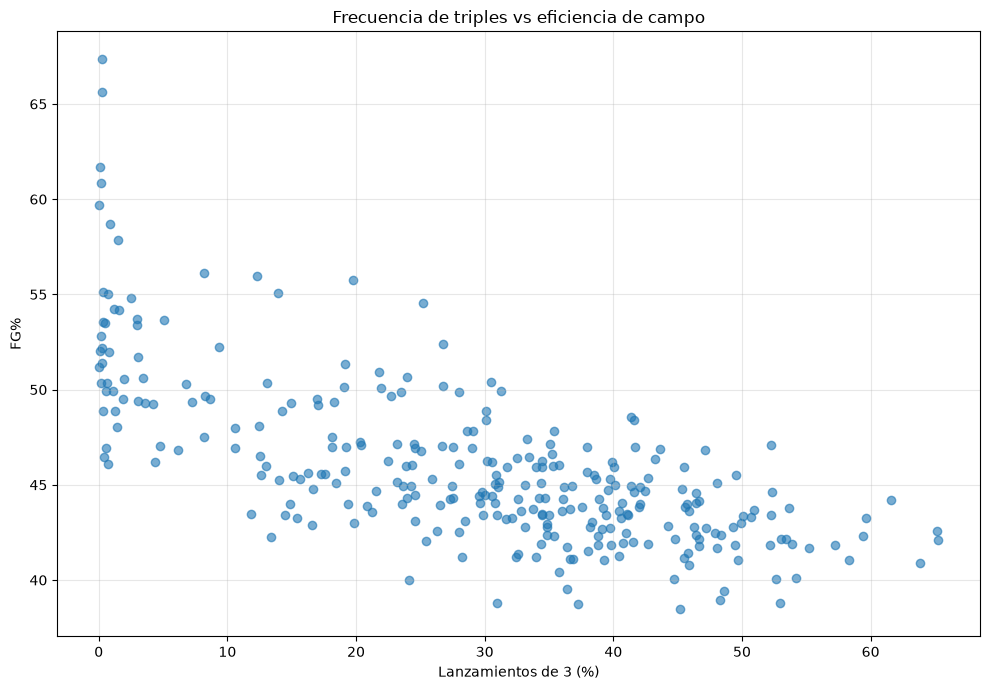

In [69]:
#Triple rate vs eficiencia
plt.figure(figsize=(10, 7))

plt.scatter(
    player_shot_profile["three_pt_rate"],
    player_shot_profile["fg_pct"],
    alpha=0.6
)

plt.title("Frecuencia de triples vs eficiencia de campo")
plt.xlabel("Lanzamientos de 3 (%)")
plt.ylabel("FG%")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [70]:
#Perfil por zonas
player_zone_profile = pd.crosstab(
    df["PLAYER_NAME"],
    df["BASIC_ZONE"],
    normalize="index"
).mul(100).round(2)

player_zone_profile.head()

BASIC_ZONE,Above the Break 3,Backcourt,In The Paint (Non-RA),Left Corner 3,Mid-Range,Restricted Area,Right Corner 3
PLAYER_NAME,,,,,,,
Adama Sanogo,0.00,0.00,26.47,0.00,0.00,73.53,0.00
Al Horford,16.13,0.03,20.08,2.22,28.64,29.52,3.39
Ayo Dosunmu,19.49,0.09,12.58,7.35,8.89,40.78,10.82
Baylor Scheierman,51.82,0.00,9.09,11.82,5.45,10.91,10.91
Ben Simmons,0.55,0.27,31.39,0.08,6.30,61.33,0.08


In [71]:
player_zone_profile.loc["Stephen Curry"]

BASIC_ZONE
Above the Break 3        44.87
Backcourt                 0.59
In The Paint (Non-RA)    10.54
Left Corner 3             3.90
Mid-Range                19.41
Restricted Area          17.83
Right Corner 3            2.85
Name: Stephen Curry, dtype: float64

In [72]:
player_zone_profile.loc[
    ["Stephen Curry", "LeBron James"]
]

BASIC_ZONE,Above the Break 3,Backcourt,In The Paint (Non-RA),Left Corner 3,Mid-Range,Restricted Area,Right Corner 3
PLAYER_NAME,,,,,,,
Stephen Curry,44.87,0.59,10.54,3.90,19.41,17.83,2.85
LeBron James,20.81,0.12,11.39,1.46,26.37,38.30,1.55


In [73]:
players_selected = [
    "Stephen Curry",
    "LeBron James",
    "DeMar DeRozan",
    "DeAndre Jordan"
]

player_comparison = player_zone_profile.loc[players_selected]

player_comparison

BASIC_ZONE,Above the Break 3,Backcourt,In The Paint (Non-RA),Left Corner 3,Mid-Range,Restricted Area,Right Corner 3
PLAYER_NAME,,,,,,,
Stephen Curry,44.87,0.59,10.54,3.90,19.41,17.83,2.85
LeBron James,20.81,0.12,11.39,1.46,26.37,38.30,1.55
DeMar DeRozan,6.50,0.17,21.18,2.50,45.12,23.10,1.44
DeAndre Jordan,0.21,0.00,8.72,0.00,1.42,89.64,0.02


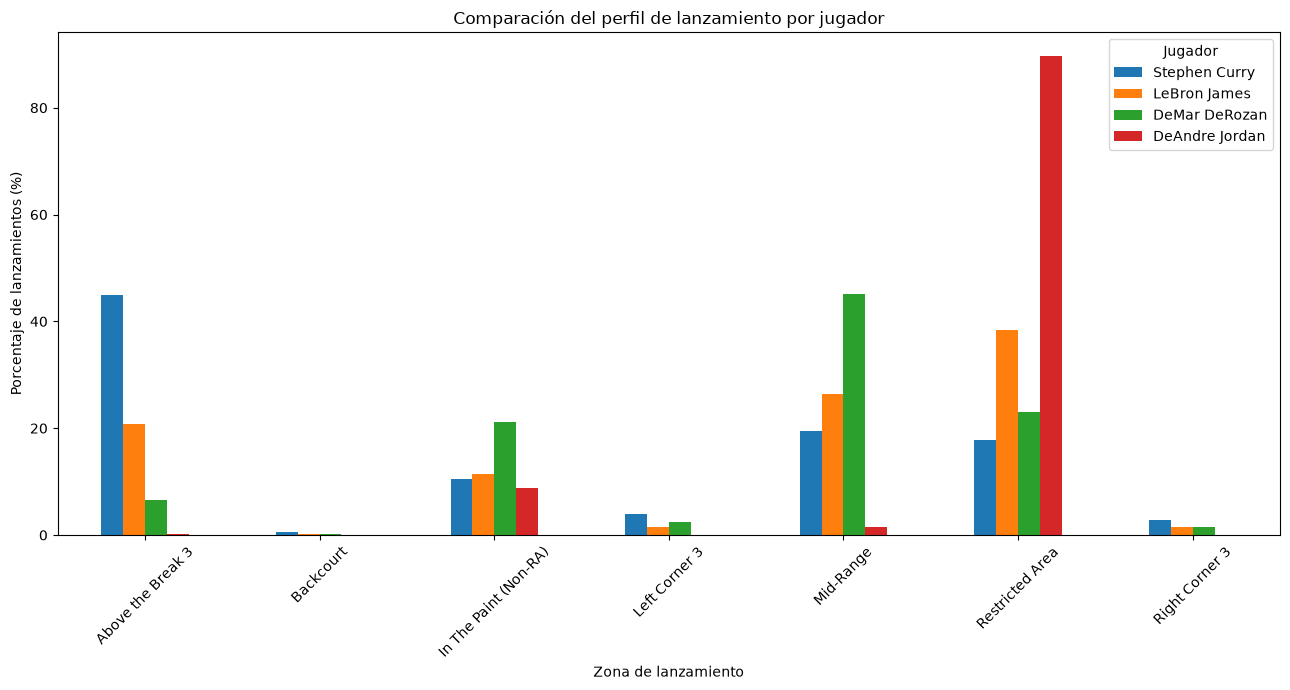

In [95]:
player_comparison.T.plot(
    kind="bar",
    figsize=(13, 7)
)

plt.title("Comparación del perfil de lanzamiento por jugador")
plt.xlabel("Zona de lanzamiento")
plt.ylabel("Porcentaje de lanzamientos (%)")
plt.xticks(rotation=45)
plt.legend(title="Jugador")
plt.tight_layout()

plt.savefig(
    "../reports/figures/player_shot_profiles.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

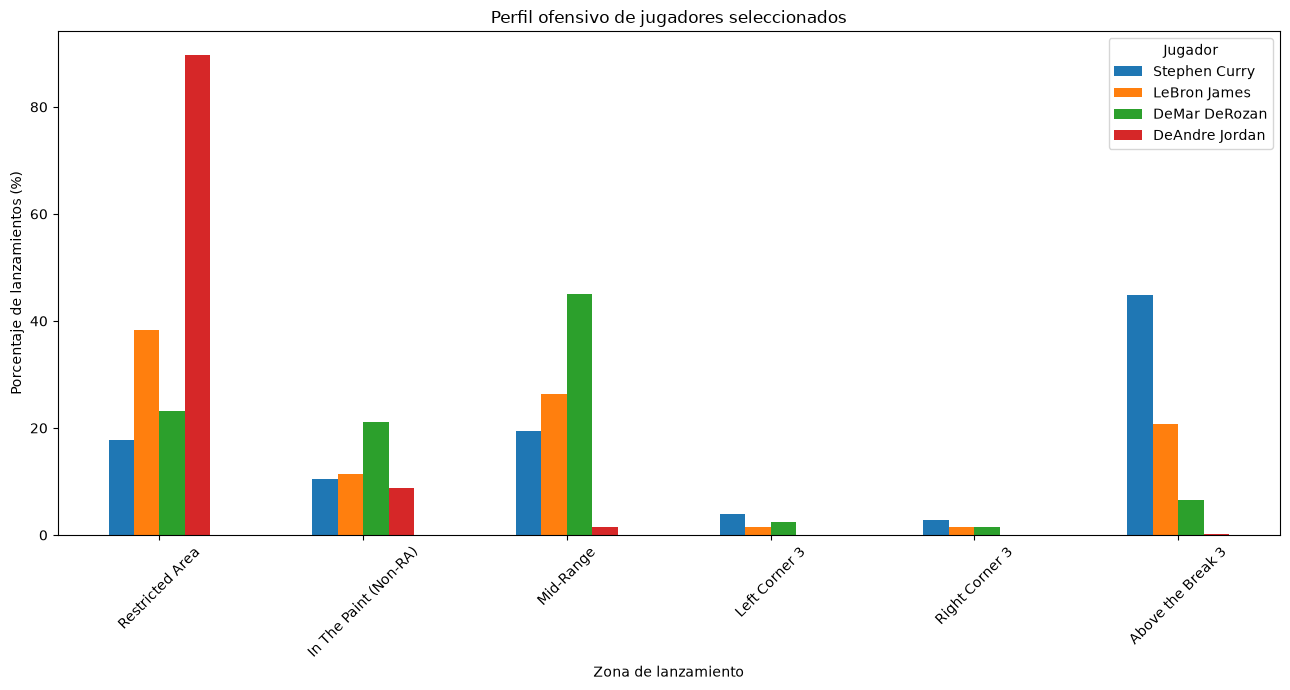

In [75]:
main_zones = [
    "Restricted Area",
    "In The Paint (Non-RA)",
    "Mid-Range",
    "Left Corner 3",
    "Right Corner 3",
    "Above the Break 3"
]

player_comparison_main = player_comparison[main_zones]

player_comparison_main.T.plot(
    kind="bar",
    figsize=(13, 7)
)

plt.title("Perfil ofensivo de jugadores seleccionados")
plt.xlabel("Zona de lanzamiento")
plt.ylabel("Porcentaje de lanzamientos (%)")
plt.xticks(rotation=45)
plt.legend(title="Jugador")
plt.tight_layout()
plt.show()

In [76]:
#Tabla resumen de los cuatro perfiles
player_summary = (
    player_analysis[
        player_analysis["PLAYER_NAME"].isin(players_selected)
    ]
    .set_index("PLAYER_NAME")
    .loc[players_selected]
)

player_summary

,attempts,made,points,avg_distance,fg_pct,points_per_attempt
PLAYER_NAME,,,,,,
Stephen Curry,18353,8646,21348,18.07,47.11,1.16
LeBron James,30581,15488,33535,11.76,50.65,1.10
DeMar DeRozan,19314,9064,18743,12.08,46.93,0.97
DeAndre Jordan,5724,3856,7714,1.47,67.37,1.35


In [77]:
three_rates = (
    player_shot_profile
    .set_index("PLAYER_NAME")["three_pt_rate"]
)

player_summary["three_pt_rate"] = three_rates

player_summary

,attempts,made,points,avg_distance,fg_pct,points_per_attempt,three_pt_rate
PLAYER_NAME,,,,,,,
Stephen Curry,18353,8646,21348,18.07,47.11,1.16,52.23
LeBron James,30581,15488,33535,11.76,50.65,1.10,23.94
DeMar DeRozan,19314,9064,18743,12.08,46.93,0.97,10.59
DeAndre Jordan,5724,3856,7714,1.47,67.37,1.35,0.23


## 12. Shot Charts

A partir de las coordenadas `LOC_X` y `LOC_Y`, se construyen mapas de lanzamiento para visualizar espacialmente los diferentes perfiles ofensivos.

Se comparan jugadores con estilos de tiro marcadamente diferentes: Stephen Curry, LeBron James, DeMar DeRozan y DeAndre Jordan.

In [78]:
#DIbujar la cancha
from matplotlib.patches import Circle, Rectangle, Arc

In [79]:
from matplotlib.patches import Circle, Rectangle, Arc


def draw_court(ax=None):
    if ax is None:
        ax = plt.gca()

    # Aro
    hoop = Circle(
        (0, 5.25),
        radius=0.75,
        fill=False,
        linewidth=1.5
    )

    # Tablero
    backboard = Rectangle(
        (-3, 4),
        6,
        0,
        linewidth=1.5,
        fill=False
    )

    # Pintura
    paint = Rectangle(
        (-8, 0),
        16,
        19,
        linewidth=1.5,
        fill=False
    )

    # Círculo de tiro libre
    free_throw = Arc(
        (0, 19),
        12,
        12,
        theta1=0,
        theta2=180,
        linewidth=1.5
    )

    # Restricted Area
    restricted = Arc(
        (0, 5.25),
        8,
        8,
        theta1=0,
        theta2=180,
        linewidth=1.5
    )

    # Líneas de triple de esquina
    ax.plot([-22, -22], [0, 14], linewidth=1.5)
    ax.plot([22, 22], [0, 14], linewidth=1.5)

    # Arco de triple
    three_arc = Arc(
        (0, 5.25),
        47.5,
        47.5,
        theta1=22,
        theta2=158,
        linewidth=1.5
    )

    for element in [
        hoop,
        backboard,
        paint,
        free_throw,
        restricted,
        three_arc
    ]:
        ax.add_patch(element)

    ax.set_xlim(-25, 25)
    ax.set_ylim(0, 47)
    ax.set_aspect("equal")
    ax.axis("off")

    return ax

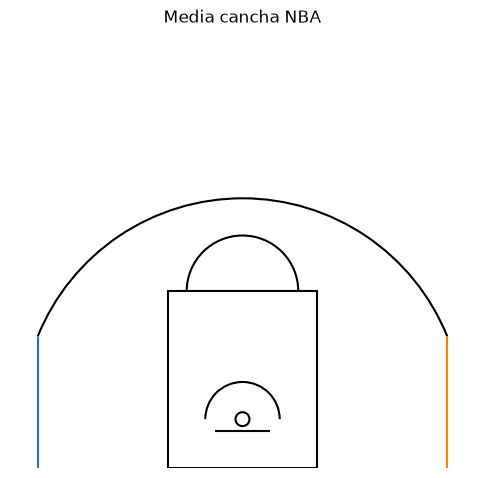

In [80]:
#Cancha sola
fig, ax = plt.subplots(figsize=(6, 6))

draw_court(ax)

plt.title("Media cancha NBA")
plt.show()

In [81]:
#Shot cart de Curry
curry_shots = df[
    df["PLAYER_NAME"] == "Stephen Curry"
]

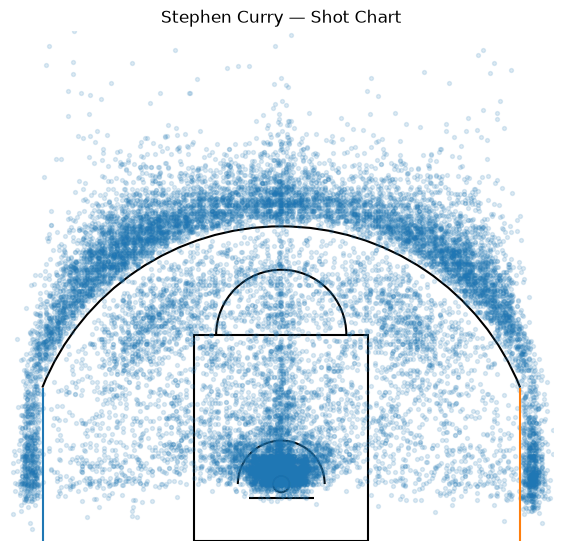

In [82]:
fig, ax = plt.subplots(figsize=(7, 7))

draw_court(ax)

ax.scatter(
    curry_shots["LOC_X"],
    curry_shots["LOC_Y"],
    s=8,
    alpha=0.15
)

plt.title("Stephen Curry — Shot Chart")
plt.show()

In [83]:
#Funcion para tener shot cart de cualquiero jugador
def plot_shot_chart(player_name):
    player_shots = df[
        df["PLAYER_NAME"] == player_name
    ]

    fig, ax = plt.subplots(figsize=(7, 7))

    draw_court(ax)

    ax.scatter(
        player_shots["LOC_X"],
        player_shots["LOC_Y"],
        s=8,
        alpha=0.15
    )

    plt.title(
        f"{player_name} — Shot Chart\n"
        f"{len(player_shots):,} lanzamientos"
    )

    plt.show()

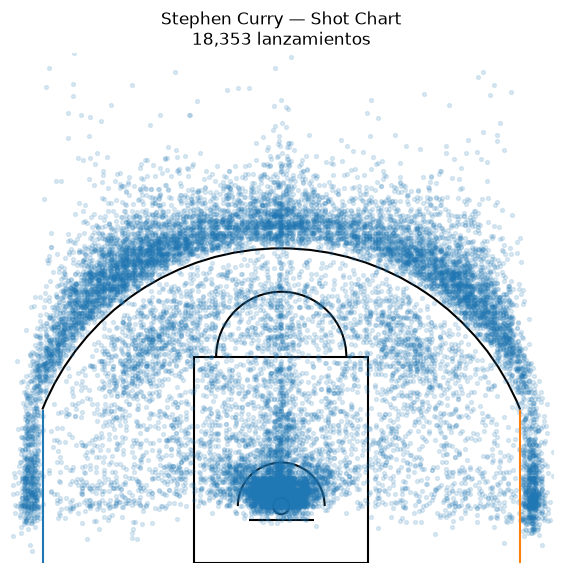

In [84]:
plot_shot_chart("Stephen Curry")

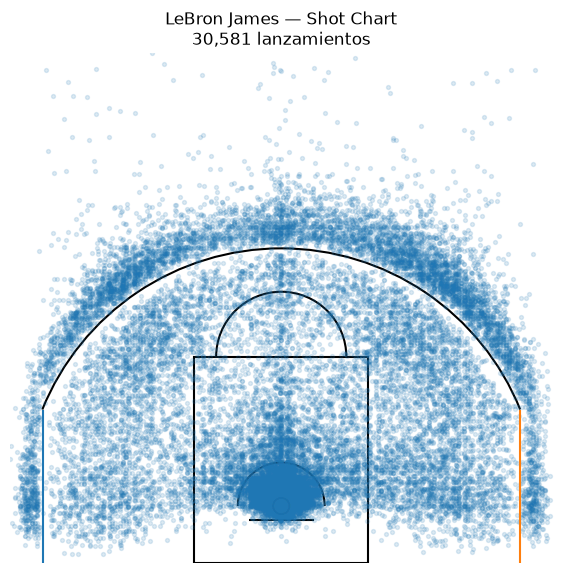

In [85]:
plot_shot_chart("LeBron James")

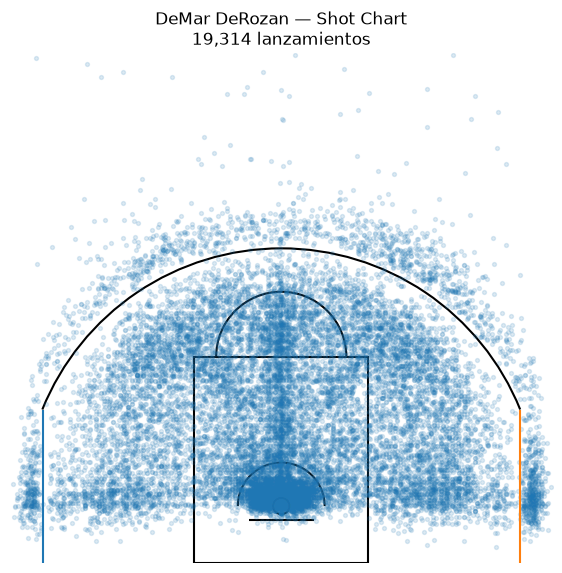

In [86]:
plot_shot_chart("DeMar DeRozan")

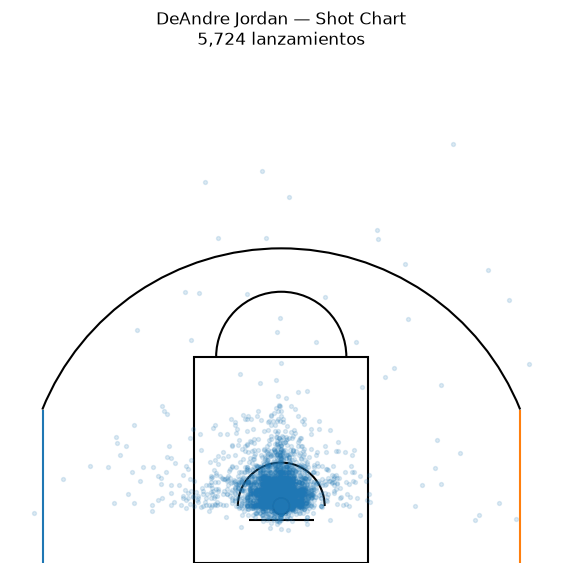

In [87]:
plot_shot_chart("DeAndre Jordan")

## 13. Shot Density Maps

Los mapas de densidad permiten identificar las zonas de la cancha donde cada jugador concentra una mayor proporción de sus lanzamientos.

A diferencia de los shot charts tradicionales, esta representación reduce el problema de superposición generado por miles de lanzamientos y facilita la comparación entre diferentes perfiles ofensivos.

In [88]:
#Función de densidad
def plot_shot_density(player_name):
    player_shots = df[
        (df["PLAYER_NAME"] == player_name) &
        (df["LOC_Y"] <= 47)
    ]

    fig, ax = plt.subplots(figsize=(7, 7))

    hexbin = ax.hexbin(
        player_shots["LOC_X"],
        player_shots["LOC_Y"],
        gridsize=30,
        mincnt=1,
        alpha=0.8
    )

    draw_court(ax)

    plt.colorbar(
        hexbin,
        ax=ax,
        label="Cantidad de lanzamientos"
    )

    plt.title(
        f"{player_name} — Densidad de lanzamientos\n"
        f"{len(player_shots):,} tiros en media cancha"
    )

    plt.show()

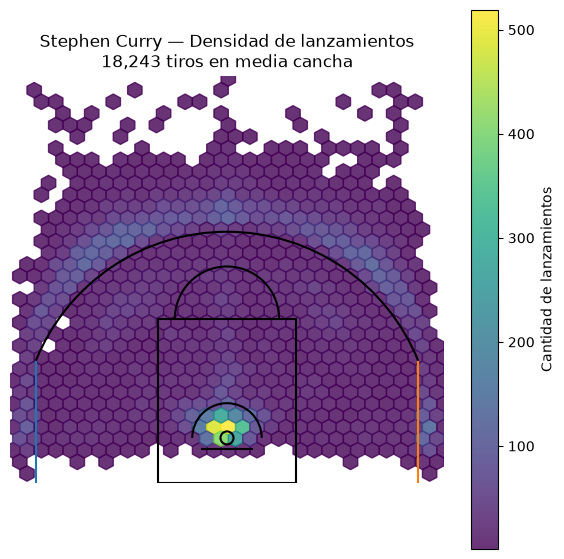

In [89]:
plot_shot_density("Stephen Curry")

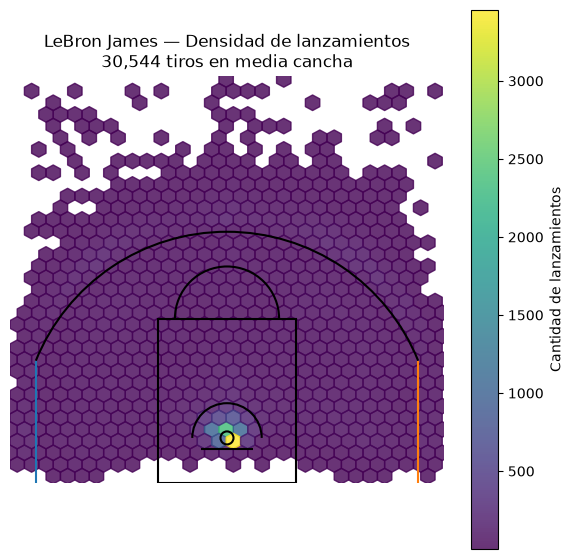

In [90]:
plot_shot_density("LeBron James")

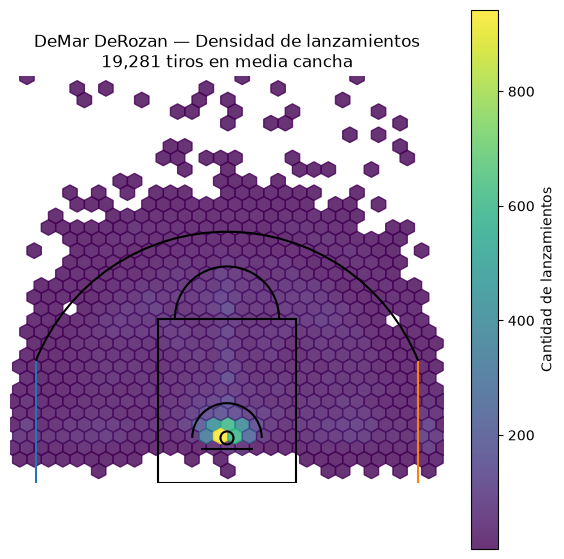

In [91]:
plot_shot_density("DeMar DeRozan")

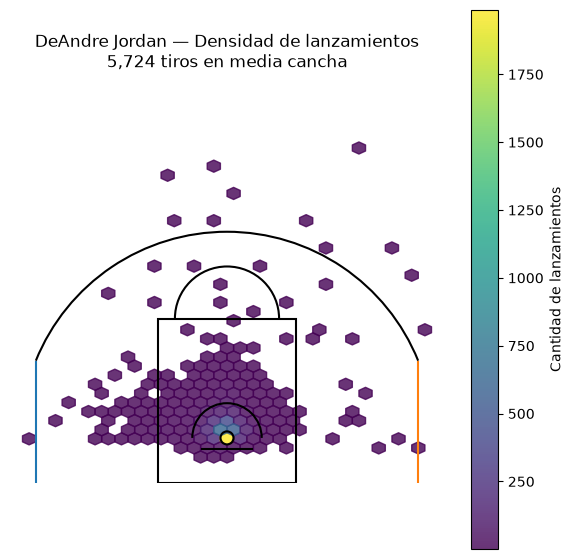

In [92]:
plot_shot_density("DeAndre Jordan")

In [93]:
profile_comparison = (
    player_zone_profile
    .loc[players_selected, main_zones]
)

profile_comparison

BASIC_ZONE,Restricted Area,In The Paint (Non-RA),Mid-Range,Left Corner 3,Right Corner 3,Above the Break 3
PLAYER_NAME,,,,,,
Stephen Curry,17.83,10.54,19.41,3.90,2.85,44.87
LeBron James,38.30,11.39,26.37,1.46,1.55,20.81
DeMar DeRozan,23.10,21.18,45.12,2.50,1.44,6.50
DeAndre Jordan,89.64,8.72,1.42,0.00,0.02,0.21


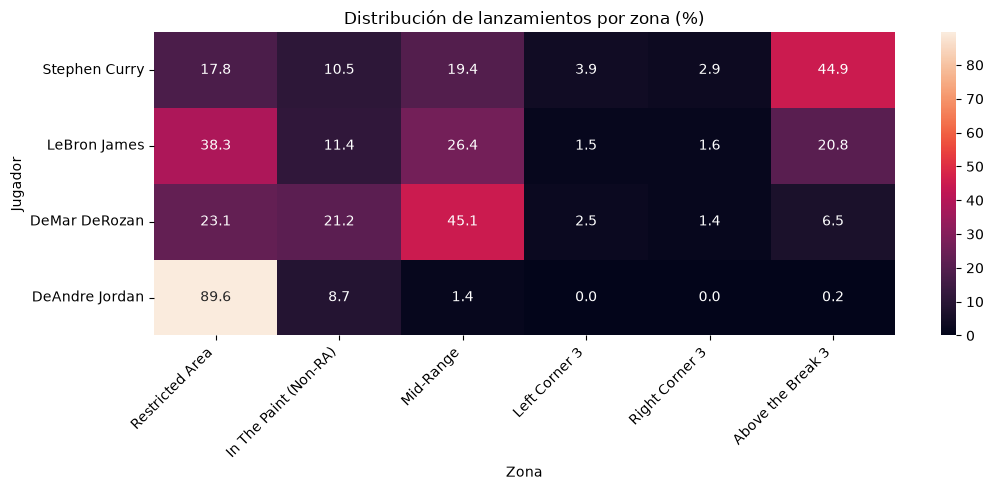

In [94]:
plt.figure(figsize=(11, 5))

sns.heatmap(
    profile_comparison,
    annot=True,
    fmt=".1f"
)

plt.title("Distribución de lanzamientos por zona (%)")
plt.xlabel("Zona")
plt.ylabel("Jugador")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 14. Conclusiones del análisis de jugadores

El análisis individual evidencia la existencia de perfiles de lanzamiento claramente diferenciados entre los jugadores.

- **Stephen Curry** presenta un perfil fuertemente orientado al tiro exterior: el 52,23 % de sus lanzamientos son triples y el 44,87 % proviene de la zona Above the Break 3. A pesar de una distancia promedio de 18,07 pies, registra 1,16 puntos por intento.

- **LeBron James** muestra un perfil más versátil, con una importante concentración de lanzamientos cerca del aro. El 38,30 % de sus intentos proviene de la Restricted Area, aunque también presenta volumen desde media y larga distancia.

- **DeMar DeRozan** se diferencia por una fuerte utilización de la media distancia, que representa el 45,12 % de sus lanzamientos, mientras que solamente el 10,59 % de sus intentos son triples.

- **DeAndre Jordan** representa un perfil prácticamente exclusivo de juego interior: el 89,64 % de sus lanzamientos proviene de la Restricted Area y su distancia promedio es de apenas 1,47 pies. Esta selección de tiro está acompañada por un FG% del 67,37 %.

Los shot charts y mapas de densidad confirman visualmente estas diferencias, mostrando cómo jugadores con roles y estilos ofensivos distintos generan perfiles espaciales de lanzamiento claramente identificables.

Estos resultados también evidencian que métricas como el FG% no deben interpretarse de forma aislada, ya que la dificultad y ubicación de los lanzamientos varían considerablemente entre jugadores.

## 15. Conclusiones generales del EDA

El análisis exploratorio permitió identificar patrones relevantes en más de cuatro millones de lanzamientos registrados a lo largo de 22 temporadas de la NBA.

### Principales hallazgos

- La selección de tiro de la NBA experimentó una transformación significativa, con un aumento de los triples del **18,70 % al 42,23 %** entre 2003-04 y 2024-25.

- Durante el mismo período, los lanzamientos de media distancia disminuyeron del **35,65 % al 9,77 %**, mostrando una clara sustitución de este tipo de lanzamiento por tiros de tres puntos.

- La distancia promedio de lanzamiento aumentó de **11,60 a 14,02 pies**, mientras que los puntos generados por intento aumentaron de **0,94 a 1,09**.

- La ubicación del lanzamiento presenta una fuerte relación con la eficiencia. Los tiros cercanos al aro registran mayores porcentajes de conversión, mientras que los lanzamientos exteriores compensan una menor probabilidad de acierto mediante su mayor valor en puntos.

- El análisis individual permitió identificar perfiles ofensivos claramente diferenciados según la distribución espacial de los lanzamientos.

- Variables como la **distancia al aro, ubicación en la cancha, zona de lanzamiento, tipo de tiro y contexto del jugador** presentan información potencialmente relevante para explicar la probabilidad de conversión.

Estos hallazgos proporcionan la base para la siguiente etapa del proyecto: desarrollar un modelo de Machine Learning capaz de estimar la probabilidad de conversión de un lanzamiento a partir de sus características.